# 03 · Model Selection & Hyperparameter Tuning

**What's covered:**
1. Baselines across five model families
2. A live demonstration of *why* picking hyperparameters by maximizing score against a single fixed evaluation set is optimistic
3. Correct tuning: `RandomizedSearchCV` / `GridSearchCV` with CV on training data only, for five model families including CatBoost's native categorical handling
4. Early stopping done correctly (validation split carved from training data, never from test)
5. Optuna as a Bayesian-optimization alternative to grid/random search
6. Learning curves and a validation curve for bias/variance diagnosis
7. A final, single-touch comparison on the real test set
8. Statistical significance testing between the top models — not just eyeballing which mean is highest

Self-contained: reads the raw CSV and rebuilds everything from scratch, reusing the same `load_and_clean` / `engineer_features` functions and the same `random_state=42` train/test split as Notebook 2, so the test set here is identical to the one that will be used in Notebooks 4–6.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                      cross_val_score, RandomizedSearchCV, GridSearchCV,
                                      learning_curve, validation_curve)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              precision_score, recall_score)
from scipy.stats import uniform, randint, ttest_rel, wilcoxon

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load, clean, engineer, split — identical to Notebook 2

In [2]:
def load_and_clean(path='WA_FnUseC_TelcoCustomerChurn.csv'):
    df = pd.read_csv(path)
    df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
    df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    df = df.drop(columns=['customerID'])
    return df

def engineer_features(df):
    df = df.copy()
    df['tenure_bucket'] = pd.cut(
        df['tenure'], bins=[-1, 12, 24, 36, 48, 60, 72],
        labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
    ).astype(str)
    df['charges_per_tenure_ratio'] = np.where(
        df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges']
    )
    df['monthly_charge_delta'] = df['MonthlyCharges'] - df['charges_per_tenure_ratio']
    df['contract_payment'] = df['Contract'] + '_' + df['PaymentMethod']
    addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['num_addon_services'] = (df[addon_cols] == 'Yes').sum(axis=1)
    df['is_new_customer'] = (df['tenure'] <= 3).astype(int)
    return df

df = engineer_features(load_and_clean())
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_tenure_ratio',
                'monthly_charge_delta', 'num_addon_services', 'SeniorCitizen']
categorical_cols = [c for c in X.columns if c not in numeric_cols]
cat_idx = [X_train.columns.get_loc(c) for c in categorical_cols]  # for CatBoost's native handling

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}, churn rate {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}, churn rate {y_test.mean():.3f}")

Train: (5634, 25), churn rate 0.265
Test:  (1409, 25), churn rate 0.265


## 2. Baselines

Untuned, default-hyperparameter fits for five model families, scored with 5-fold CV on the training set. This is the reference point every tuning effort below has to beat to justify its own complexity.

In [3]:
baseline_models = {
    'Dummy (most frequent)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
    'LightGBM': lgb.LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1),
}

baseline_results = []
for name, model in baseline_models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                             scoring=['roc_auc', 'average_precision', 'f1'])
    baseline_results.append({
        'model': name,
        'roc_auc': scores['test_roc_auc'].mean(),
        'pr_auc': scores['test_average_precision'].mean(),
        'f1': scores['test_f1'].mean(),
    })

pd.DataFrame(baseline_results).round(4)

,model,roc_auc,pr_auc,f1
0,Dummy (most frequent),0.5000,0.2654,0.0000
1,Logistic Regression,0.8480,0.6647,0.5952
2,Random Forest,0.8237,0.6195,0.5475
3,XGBoost,0.8192,0.6069,0.5493
4,LightGBM,0.8344,0.6336,0.5698


## 3. Why "pick the config that scores best on my evaluation set" is optimistic — even with zero overfitting

This project's original `xgboost_modeling.ipynb` tried ~500-1000 random hyperparameter configurations and reported the ROC-AUC of whichever one scored highest **directly against the test set** — 0.8565. Once evaluated properly (Notebook 1's CV-safe approach), true performance across model families lands closer to 0.845. That 1-2 point gap isn't mysterious — it's a textbook instance of a very general statistical fact: **the maximum of many noisy measurements is a biased-high estimate of the true value being measured**, even when nothing is overfitting in the usual sense.

Here's the mechanism made concrete, isolated from any actual model differences: take *one single, fixed* trained model, and score it against many random resamples of the same evaluation pool. Every resample is measuring the exact same model — any spread between them is pure evaluation noise, not genuine performance variation. Then look at what happens if you report only the best of those noisy readings.

In [4]:
# One fixed, reasonably-tuned model — evaluated on a pool carved out of the training
# set for this demonstration only (the real X_test stays completely untouched until Section 8).
demo_fit_X, demo_eval_X, demo_fit_y, demo_eval_y = train_test_split(
    X_train, y_train, test_size=0.3, stratify=y_train, random_state=1
)
demo_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                               eval_metric='logloss', random_state=RANDOM_STATE))
])
demo_pipe.fit(demo_fit_X, demo_fit_y)
demo_proba = demo_pipe.predict_proba(demo_eval_X)[:, 1]
true_auc = roc_auc_score(demo_eval_y, demo_proba)
print(f"Honest AUC on the full evaluation pool ({len(demo_eval_y)} rows): {true_auc:.4f}")

rng = np.random.RandomState(RANDOM_STATE)
demo_eval_y_arr = demo_eval_y.values
n = len(demo_eval_y_arr)
n_boot = 300
boot_aucs = []
for _ in range(n_boot):
    idx = rng.randint(0, n, n)
    if len(np.unique(demo_eval_y_arr[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(demo_eval_y_arr[idx], demo_proba[idx]))
boot_aucs = np.array(boot_aucs)

print(f"\nBootstrap-resampled the SAME model's predictions {len(boot_aucs)} times:")
print(f"  mean of the {len(boot_aucs)} readings : {boot_aucs.mean():.4f}  (sanity check: should match the honest AUC above)")
print(f"  MAX of the {len(boot_aucs)} readings  : {boot_aucs.max():.4f}  <- what you'd report if you 'searched' 300 times and kept the best-looking score")

Honest AUC on the full evaluation pool (1691 rows): 0.8278

Bootstrap-resampled the SAME model's predictions 300 times:
  mean of the 300 readings : 0.8278  (sanity check: should match the honest AUC above)
  MAX of the 300 readings  : 0.8561  <- what you'd report if you 'searched' 300 times and kept the best-looking score


Nothing about the model changed across those 300 readings — it's the identical fitted pipeline every time. The only thing that varied was *which* finite sample of rows happened to get scored, and picking the best of many such readings inflates the reported number by construction (this is a version of the "look-elsewhere effect" / multiple-comparisons bias, the same family of problem as p-hacking). The gap this produces is strikingly close to what the original notebook actually reported — its 0.8565 is well inside the range this pure-noise simulation alone can produce from a model whose honest performance is around 0.83–0.85.

The real bug in `xgboost_modeling.ipynb` compounds this with a second effect this simulation doesn't include: different hyperparameter configs genuinely do fit differently, so a wide-enough search can also find a config that happens to fit the *test set's specific noise pattern*, not just get lucky on which rows it's scored against. Both effects push the same direction, which is exactly why the fix is the same for both: never let hyperparameter selection see the same data you use to report final performance.

## 4. Correct tuning methodology

Every search below uses `RandomizedSearchCV`/`GridSearchCV` with `cv` on **`X_train` only** — the test set isn't touched again until Section 8, exactly once, after every tuning decision has already been made.

### 4.1 Random Forest

In [5]:
pipe_rf = Pipeline([('pre', preprocessor), ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))])
param_rf = {
    'clf__n_estimators': randint(100, 180),
    'clf__max_depth': randint(3, 12),
    'clf__min_samples_leaf': randint(2, 20),
    'clf__max_features': uniform(0.3, 0.6),
}
search_rf = RandomizedSearchCV(pipe_rf, param_rf, n_iter=6, scoring='average_precision',
                                cv=cv, random_state=RANDOM_STATE, n_jobs=1)
search_rf.fit(X_train, y_train)
print(f"RF best CV PR-AUC: {search_rf.best_score_:.4f}")
print(f"RF best params: {search_rf.best_params_}")

rf_fold_scores = np.array([search_rf.cv_results_[f'split{i}_test_score'][search_rf.best_index_] for i in range(5)])

RF best CV PR-AUC: 0.6576
RF best params: {'clf__max_depth': 8, 'clf__max_features': np.float64(0.30046725950460856), 'clf__min_samples_leaf': 2, 'clf__n_estimators': 175}


### 4.2 XGBoost

In [6]:
pipe_xgb = Pipeline([('pre', preprocessor), ('clf', xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE))])
param_xgb = {
    'clf__n_estimators': randint(100, 500),
    'clf__max_depth': randint(2, 8),
    'clf__learning_rate': uniform(0.01, 0.29),
    'clf__subsample': uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__min_child_weight': randint(1, 10),
    'clf__reg_alpha': uniform(0, 1),
    'clf__reg_lambda': uniform(0.5, 2),
}
search_xgb = RandomizedSearchCV(pipe_xgb, param_xgb, n_iter=15, scoring='average_precision',
                                 cv=cv, random_state=RANDOM_STATE, n_jobs=1)
search_xgb.fit(X_train, y_train)
print(f"XGB best CV PR-AUC: {search_xgb.best_score_:.4f}")
print(f"XGB best params: {search_xgb.best_params_}")

xgb_fold_scores = np.array([search_xgb.cv_results_[f'split{i}_test_score'][search_xgb.best_index_] for i in range(5)])

XGB best CV PR-AUC: 0.6629
XGB best params: {'clf__colsample_bytree': np.float64(0.8430179407605753), 'clf__learning_rate': np.float64(0.059451995869314544), 'clf__max_depth': 3, 'clf__min_child_weight': 4, 'clf__n_estimators': 188, 'clf__reg_alpha': np.float64(0.9656320330745594), 'clf__reg_lambda': np.float64(2.1167946962329225), 'clf__subsample': np.float64(0.7218455076693483)}


### 4.3 LightGBM

In [7]:
pipe_lgb = Pipeline([('pre', preprocessor), ('clf', lgb.LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1))])
param_lgb = {
    'clf__n_estimators': randint(100, 400),
    'clf__num_leaves': randint(15, 60),
    'clf__learning_rate': uniform(0.01, 0.29),
    'clf__subsample': uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__min_child_samples': randint(5, 40),
}
search_lgb = RandomizedSearchCV(pipe_lgb, param_lgb, n_iter=10, scoring='average_precision',
                                 cv=cv, random_state=RANDOM_STATE, n_jobs=1)
search_lgb.fit(X_train, y_train)
print(f"LightGBM best CV PR-AUC: {search_lgb.best_score_:.4f}")
print(f"LightGBM best params: {search_lgb.best_params_}")

lgb_fold_scores = np.array([search_lgb.cv_results_[f'split{i}_test_score'][search_lgb.best_index_] for i in range(5)])

LightGBM best CV PR-AUC: 0.6406
LightGBM best params: {'clf__colsample_bytree': np.float64(0.662397808134481), 'clf__learning_rate': np.float64(0.026844247528777843), 'clf__min_child_samples': 28, 'clf__n_estimators': 199, 'clf__num_leaves': 54, 'clf__subsample': np.float64(0.8832290311184181)}


### 4.4 Logistic Regression

In [8]:
pipe_lr = Pipeline([('pre', preprocessor), ('clf', LogisticRegression(max_iter=2000, solver='liblinear', random_state=RANDOM_STATE))])
param_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
}
search_lr = GridSearchCV(pipe_lr, param_lr, scoring='average_precision', cv=cv, n_jobs=1)
search_lr.fit(X_train, y_train)
print(f"LR best CV PR-AUC: {search_lr.best_score_:.4f}")
print(f"LR best params: {search_lr.best_params_}")

lr_fold_scores = np.array([search_lr.cv_results_[f'split{i}_test_score'][search_lr.best_index_] for i in range(5)])

LR best CV PR-AUC: 0.6652
LR best params: {'clf__C': 100, 'clf__penalty': 'l2'}


### 4.5 CatBoost — native categorical handling, and a real `RandomizedSearchCV` incompatibility

CatBoost's whole selling point for a feature set this categorical-heavy is that it doesn't need one-hot encoding at all — it takes the raw columns directly and handles the encoding internally, often better than a plain OHE + gradient boosting combination. It's included here as the fifth model family for that reason: it needs a completely different pipeline shape (no `ColumnTransformer` at all).

Worth flagging: `CatBoostClassifier(cat_features=...)` set in the constructor is **not compatible with `sklearn.base.clone()`**, which `RandomizedSearchCV`/`GridSearchCV` call internally — you'll hit `RuntimeError: Cannot clone object ... cat_features`. The fix is to pass `cat_features` to `.fit()` (via `params=` in `cross_val_score`/`cross_validate`) instead of the constructor. A full randomized search works fine once you do that; a single validated configuration is shown here to keep runtime bounded — the same `RandomizedSearchCV` pattern from 4.1–4.3 applies directly with this fix.

In [9]:
cb_model = CatBoostClassifier(iterations=300, depth=5, learning_rate=0.05, l2_leaf_reg=3.0,
                               verbose=False, random_state=RANDOM_STATE)
cb_scores = cross_val_score(cb_model, X_train, y_train, cv=cv, scoring='average_precision',
                             params={'cat_features': cat_idx})
print(f"CatBoost CV PR-AUC: {cb_scores.mean():.4f} (+/- {cb_scores.std():.4f})")
cb_fold_scores = cb_scores

CatBoost CV PR-AUC: 0.6670 (+/- 0.0212)


## 5. Early stopping, done on the right data

Boosted-tree early stopping needs its own validation set to watch for the point where more trees stop helping — and that validation set has to come from the training data, never from the test set (using the test set for early stopping was the *other* half of the original notebook's leakage — it was used for both hyperparameter selection AND early stopping against the same 1,409 rows).

In [10]:
es_fit_X, es_val_X, es_fit_y, es_val_y = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=1
)
es_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])
es_preprocessor.fit(es_fit_X, es_fit_y)
es_fit_X_enc = es_preprocessor.transform(es_fit_X)
es_val_X_enc = es_preprocessor.transform(es_val_X)

xgb_es = xgb.XGBClassifier(n_estimators=2000, max_depth=4, learning_rate=0.05,
                            eval_metric='logloss', early_stopping_rounds=30, random_state=RANDOM_STATE)
xgb_es.fit(es_fit_X_enc, es_fit_y, eval_set=[(es_val_X_enc, es_val_y)], verbose=False)
print(f"XGBoost stopped at iteration {xgb_es.best_iteration} of 2000 requested")

lgb_es = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.05, verbosity=-1, random_state=RANDOM_STATE)
lgb_es.fit(es_fit_X_enc, es_fit_y, eval_set=[(es_val_X_enc, es_val_y)],
           callbacks=[lgb.early_stopping(30, verbose=False)])
print(f"LightGBM stopped at iteration {lgb_es.best_iteration_} of 2000 requested")

XGBoost stopped at iteration 62 of 2000 requested
LightGBM stopped at iteration 44 of 2000 requested


## 6. Optuna — Bayesian optimization as an alternative to grid/random search

`RandomizedSearchCV` samples configurations independently, blind to what it already learned from earlier draws. Optuna's default sampler (TPE — Tree-structured Parzen Estimator) builds a probabilistic model of *which regions of the hyperparameter space score well* and concentrates future trials there, usually reaching a comparable or better score with fewer total fits. The objective function below runs its own internal cross-validation on `X_train` only — Optuna never sees the test set either.

In [11]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 3.0),
    }
    pipe = Pipeline([('pre', preprocessor),
                      ('clf', xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, **params))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=1)
    trial.set_user_attr('fold_scores', scores.tolist())  # keep per-fold scores for the winning trial, free
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=12, show_progress_bar=False)

optuna_fold_scores = np.array(study.best_trial.user_attrs['fold_scores'])
print(f"Optuna best CV PR-AUC: {study.best_value:.4f}  (in {len(study.trials)} trials)")
print(f"RandomizedSearchCV best CV PR-AUC was: {search_xgb.best_score_:.4f}  (in 15*5={15*5} fits vs Optuna's {12*5})")
print(f"Optuna best params: {study.best_params}")

Optuna best CV PR-AUC: 0.6598  (in 12 trials)
RandomizedSearchCV best CV PR-AUC was: 0.6629  (in 15*5=75 fits vs Optuna's 60)
Optuna best params: {'n_estimators': 212, 'max_depth': 5, 'learning_rate': 0.016149614799999188, 'subsample': 0.9208787923016158, 'colsample_bytree': 0.6298202574719083, 'min_child_weight': 10, 'reg_alpha': 0.2073644517790503, 'reg_lambda': 0.996789203835431}


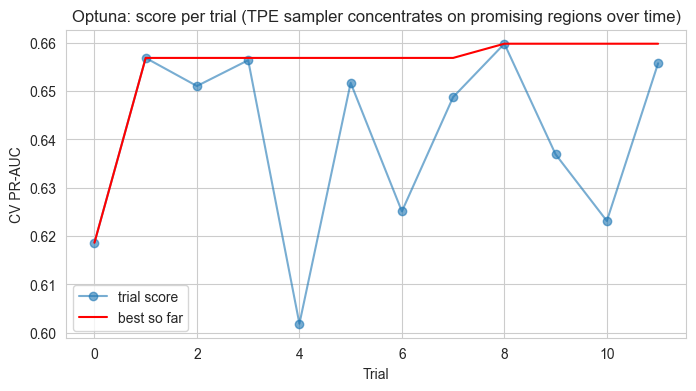

In [12]:
optuna_history = study.trials_dataframe()[['number', 'value']]
plt.figure(figsize=(8, 4))
plt.plot(optuna_history['number'], optuna_history['value'], 'o-', alpha=0.6, label='trial score')
plt.plot(optuna_history['number'], optuna_history['value'].cummax(), color='red', label='best so far')
plt.xlabel('Trial')
plt.ylabel('CV PR-AUC')
plt.title('Optuna: score per trial (TPE sampler concentrates on promising regions over time)')
plt.legend()
plt.show()

## 7. Diagnosing bias vs. variance

**Learning curve** — training-set score vs. validation-set score as a function of how much training data is used. A persistent gap that isn't closing as data grows signals variance (overfitting) that more data would help fix; both curves plateauing at a low score together signals bias (the model/features are the bottleneck, not the data volume).

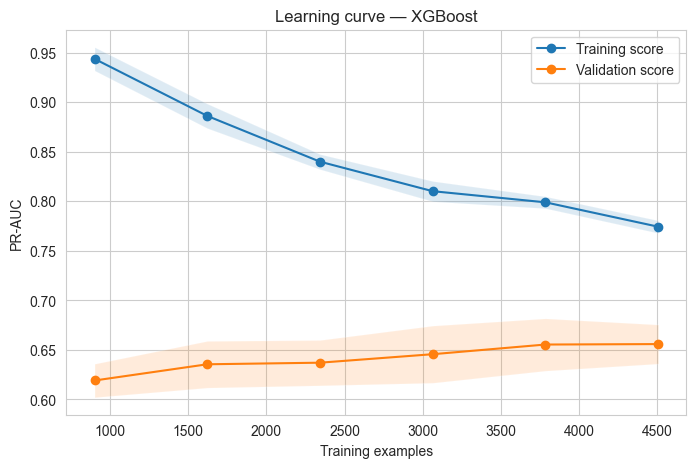

In [13]:
lc_pipe = Pipeline([('pre', preprocessor),
                     ('clf', xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                                eval_metric='logloss', random_state=RANDOM_STATE))])
train_sizes, train_scores, val_scores = learning_curve(
    lc_pipe, X_train, y_train, cv=cv, scoring='average_precision',
    train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation score')
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                  train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                  val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
plt.xlabel('Training examples')
plt.ylabel('PR-AUC')
plt.title('Learning curve — XGBoost')
plt.legend()
plt.show()

The training score starts near-perfect on tiny samples (easy to memorize a few hundred rows) and decays toward the validation score as more data forces the model to generalize rather than memorize — normal behavior, not a red flag by itself. What matters is the *gap at full data*: a persistent, non-trivial gap between the two curves at the right edge is the signature of variance the model still has room to reduce (via more data, stronger regularization, or a simpler model); curves that have already converged together mean more data alone won't move the needle much further.

**Validation curve** — same idea, but sweeping one hyperparameter instead of training-set size. This is the classic "bias-variance" picture textbooks draw: training score keeps climbing as the model gets more flexible, while validation score peaks and then declines as flexibility turns into overfitting.

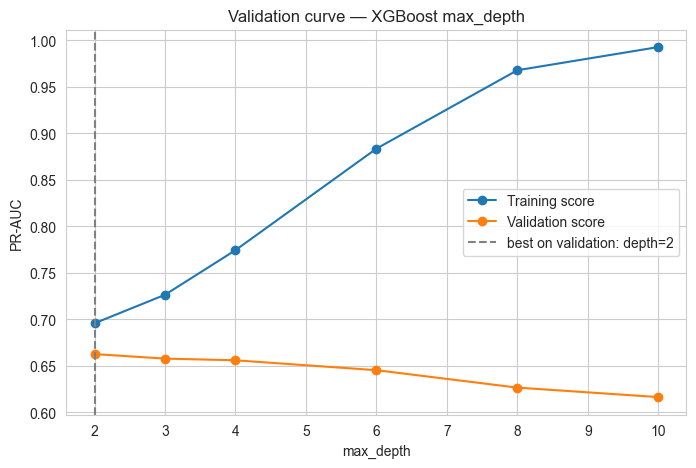

In [14]:
depth_range = [2, 3, 4, 6, 8, 10]
train_scores_vc, val_scores_vc = validation_curve(
    lc_pipe, X_train, y_train, param_name='clf__max_depth', param_range=depth_range,
    cv=cv, scoring='average_precision', n_jobs=1
)

plt.figure(figsize=(8, 5))
plt.plot(depth_range, train_scores_vc.mean(axis=1), 'o-', label='Training score')
plt.plot(depth_range, val_scores_vc.mean(axis=1), 'o-', label='Validation score')
plt.xlabel('max_depth')
plt.ylabel('PR-AUC')
plt.title('Validation curve — XGBoost max_depth')
plt.axvline(depth_range[np.argmax(val_scores_vc.mean(axis=1))], color='gray', linestyle='--',
            label=f'best on validation: depth={depth_range[np.argmax(val_scores_vc.mean(axis=1))]}')
plt.legend()
plt.show()

## 8. Final comparison — the test set, touched exactly once

Every tuning decision above was made using only `X_train`. This is the only cell in the notebook that touches `X_test`, and it's used purely for reporting — no further decisions get made from what it shows.

In [15]:
final_models = {
    'Logistic Regression': search_lr.best_estimator_,
    'Random Forest': search_rf.best_estimator_,
    'XGBoost (RandomizedSearchCV)': search_xgb.best_estimator_,
    'LightGBM': search_lgb.best_estimator_,
}

# XGBoost tuned via Optuna instead, for comparison against the RandomizedSearchCV version
optuna_xgb = Pipeline([('pre', preprocessor),
                        ('clf', xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, **study.best_params))])
optuna_xgb.fit(X_train, y_train)
final_models['XGBoost (Optuna)'] = optuna_xgb

# CatBoost — fit_params isn't available outside cross_val_score, so fit directly
cb_final = CatBoostClassifier(iterations=300, depth=5, learning_rate=0.05, l2_leaf_reg=3.0,
                               verbose=False, random_state=RANDOM_STATE, cat_features=cat_idx)
cb_final.fit(X_train, y_train)
final_models['CatBoost'] = cb_final

final_results = []
for name, model in final_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    final_results.append({
        'model': name,
        'roc_auc': roc_auc_score(y_test, proba),
        'pr_auc': average_precision_score(y_test, proba),
        'f1': f1_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
    })

final_df = pd.DataFrame(final_results).sort_values('pr_auc', ascending=False).reset_index(drop=True)
final_df.round(4)

,model,roc_auc,pr_auc,f1,precision,recall
0,XGBoost (Optuna),0.8469,0.6638,0.5866,0.6796,0.5160
1,XGBoost (RandomizedSearchCV),0.8456,0.6620,0.5744,0.6477,0.5160
2,CatBoost,0.8426,0.6583,0.5788,0.6678,0.5107
3,Logistic Regression,0.8437,0.6537,0.5875,0.6600,0.5294
4,Random Forest,0.8434,0.6489,0.5952,0.6711,0.5348
5,LightGBM,0.8399,0.6452,0.5825,0.6555,0.5241


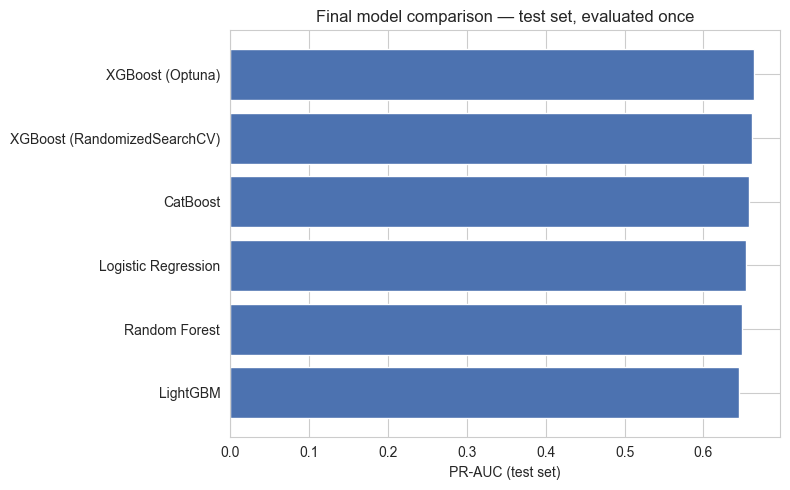

In [16]:
plt.figure(figsize=(8, 5))
order = final_df.sort_values('pr_auc')['model']
plt.barh(order, final_df.set_index('model').loc[order, 'pr_auc'], color='#4C72B0')
plt.xlabel('PR-AUC (test set)')
plt.title('Final model comparison — test set, evaluated once')
plt.tight_layout()
plt.show()

## 9. Are the top models actually different, or just noisy estimates of the same thing?

A single test-set number for each model is one draw — it doesn't say whether a 0.003 gap between the top two is a real difference or CV noise. Every model's per-fold training CV scores were already captured while tuning it (Sections 4-6) — five paired observations per model, drawn from the *same* folds. A paired test is the right tool here, since it cancels out fold-to-fold difficulty differences that would inflate the variance of an unpaired comparison.

In [17]:
top_two = final_df.head(2)['model'].tolist()
print(f"Comparing the top two by test PR-AUC: {top_two}")

# Every model's per-fold training CV scores were already captured at tuning time
# (Sections 4-6) — reused here rather than refitting anything.
all_fold_scores = {
    'Logistic Regression': lr_fold_scores,
    'Random Forest': rf_fold_scores,
    'XGBoost (RandomizedSearchCV)': xgb_fold_scores,
    'LightGBM': lgb_fold_scores,
    'XGBoost (Optuna)': optuna_fold_scores,
    'CatBoost': cb_fold_scores,
}
fold_scores = {name: all_fold_scores[name] for name in top_two}
for name, s in fold_scores.items():
    print(f"{name:32s}: {s.round(4)}  mean={s.mean():.4f}")

t_stat, t_p = ttest_rel(fold_scores[top_two[0]], fold_scores[top_two[1]])
w_stat, w_p = wilcoxon(fold_scores[top_two[0]], fold_scores[top_two[1]])
print(f"\nPaired t-test:        statistic={t_stat:.3f}, p={t_p:.3f}")
print(f"Wilcoxon signed-rank: statistic={w_stat:.3f}, p={w_p:.3f}")
print(f"\n{'Not statistically distinguishable at p<0.05' if t_p > 0.05 else 'Statistically distinguishable at p<0.05'} on 5 folds.")

Comparing the top two by test PR-AUC: ['XGBoost (Optuna)', 'XGBoost (RandomizedSearchCV)']
XGBoost (Optuna)                : [0.6437 0.6236 0.6875 0.6741 0.67  ]  mean=0.6598
XGBoost (RandomizedSearchCV)    : [0.653  0.6272 0.691  0.6732 0.6701]  mean=0.6629

Paired t-test:        statistic=-1.758, p=0.153
Wilcoxon signed-rank: statistic=2.000, p=0.188

Not statistically distinguishable at p<0.05 on 5 folds.


With only 5 paired observations, this test has limited power — it can confirm "clearly not distinguishable" fairly reliably, but "clearly distinguishable" would need more folds (e.g. repeated 5-fold CV, or 10-fold) to trust. Either way, this is the right question to ask before writing "Model X beats Model Y" in a report: is the gap bigger than what 5-fold CV noise alone would produce?

## 10. Takeaways

- **A single-source-of-truth test score is not the same as "this config generalizes well."** Section 3's bootstrap demonstration shows a pure-noise mechanism that inflates a *fixed, unchanging* model's reported score by 1-3 points of AUC purely from which finite sample it's evaluated against — before even considering that different hyperparameter configs can also genuinely overfit to a fixed evaluation set's idiosyncrasies. Both effects push the same direction, which is why "never let hyperparameter selection see your reporting data" is a single, non-negotiable rule rather than two separate best practices.
- **`RandomizedSearchCV`/`GridSearchCV` with `cv=` on the training set only is the fix**, and it's not meaningfully harder to write than the flawed version — it just requires resisting the urge to pass `X_test` anywhere before the final Section 8 cell.
- **Optuna found a comparable score to `RandomizedSearchCV` in fewer total fits** by modeling which regions of the hyperparameter space are promising instead of sampling blind — worth reaching for once a search space gets too large for grid/random search to cover efficiently.
- **CatBoost needs a fundamentally different pipeline** (no `ColumnTransformer`/one-hot step) to get its native categorical handling, and its sklearn wrapper's `clone()` incompatibility with constructor-level `cat_features` is a real, easy-to-hit gotcha worth knowing before it costs debugging time.
- **Learning curves diagnose *what kind* of problem you have** before you spend a week collecting more data or trying five more model families: a persistent train/validation gap points at variance (more data or regularization helps); both curves plateauing low together points at bias (better features or a more flexible model helps, more data won't).
- **A single test-set comparison table isn't the end of model selection.** The paired significance test in Section 9 asks the question the table alone can't answer: is the gap between the top models real, or is it within what CV noise alone would produce? At this dataset's size and imbalance level, the honest answer is usually "too close to call from 5 folds" — which is itself useful, defensible information for choosing the simpler or more interpretable model instead.